# I. Installation des dépendances

In [3]:
!sudo apt-get update
!sudo apt-get install p7zip*
!pip install -r requirements.txt
!conda install -y graph-tool

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Hit:3 https://ppa.launchpadcontent.net/git-core/ppa/ubuntu jammy InRelease     
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://apt.postgresql.org/pub/repos/apt jammy-pgdg InRelease [129 kB]   
Get:7 https://apt.postgresql.org/pub/repos/apt jammy-pgdg/main amd64 Packages [580 kB]
Fetched 966 kB in 1s (724 kB/s)  
Reading package lists... Done
W: https://apt.postgresql.org/pub/repos/apt/dists/jammy-pgdg/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'p7zip-rar' for glob 'p7zip*'
Note, selecting 'p7zip-full' for glob 'p7zip*'
Note, selecting

# II. Récupération et traitement des données

Les données téléchargées occupent beaucoup d'espace (prévoir au moins 20 Go)

Nous commençons par les données d'OpenStreetMaps.
Nous récupérons le graphe du réseau routier de New York, le projetons selon EPSG:32618, ajoutons des métadonnées utiles et le renumérotons.

In [4]:
import osmnx
import networkx
import solver
import data_management
import data_processing


osmnx.settings.log_console = True
osmnx.settings.use_cache = True

graph = osmnx.graph.graph_from_place("New York", network_type="drive")
graph = osmnx.project_graph(graph)
graph = osmnx.routing.add_edge_speeds(graph)
graph = osmnx.routing.add_edge_travel_times(graph)
graph = networkx.convert_node_labels_to_integers(graph)

Puis nous téléchargeons les données du traffic newyorkais. \
Nous nettyons le jeu de données sur les trajets des taxis, en enlevant notamment les valeurs aberrantes (voir la fonction clean_thread_job du fichier data_management.py pour plus de détails). \
Enfin, nous assignons à chaque point de récupération et de dépôt des trajets de taxis l'intersection de rue la plus proche, afin de faciliter le traitement par la suite.

In [ ]:
data_management.download_datasets("data")
data_management.clean_datasets("data/FOIL2013")
data_processing.preprocess_datasets(graph, "data/FOIL2013")

# II. Statistiques descriptives

Commençons par voir à quoi ressemble le réseau.

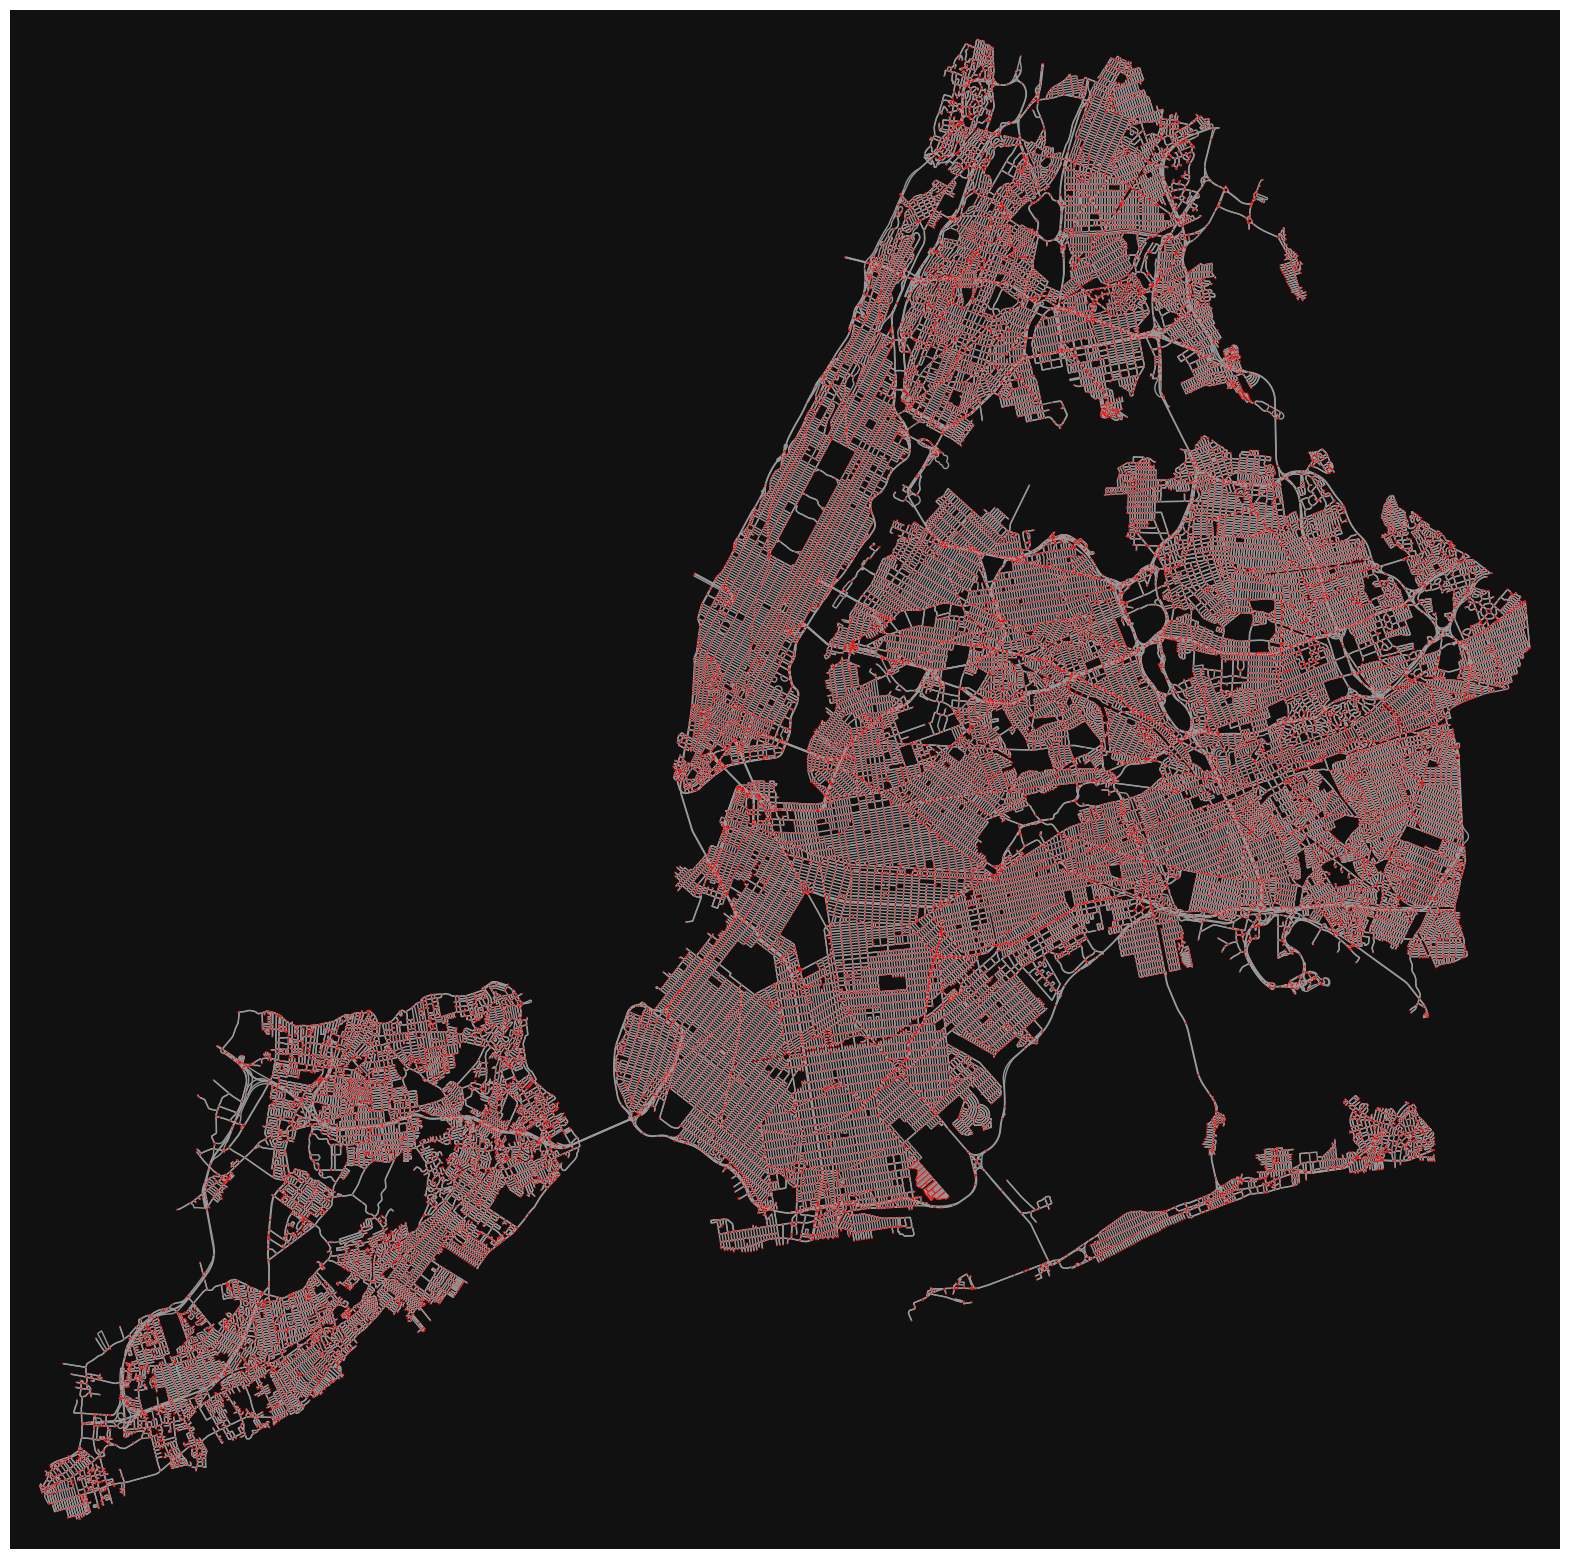

(<Figure size 2000x2000 with 1 Axes>, <Axes: >)

In [9]:
osmnx.plot.plot_graph(graph, node_size=1, figsize=(20, 20), node_color="#ff0000")

Regardons déjà quelle est la taille du réseau considéré : nombre de nœuds, nombre d'arêtes et longueur totale.

In [10]:
print(graph.order())
print(graph.number_of_edges())
total_length = 0
for u, v, data in graph.edges(data=True): 
    total_length += data.get("length", 0)
print(total_length)

55299
139461
16154392.80734664


Les deux premières grandeurs rendent comptent de la complexité du réseau, et seront importantes par la suite lors de la modélisation. En effet, le solveur est assez lent donc il est crucial de garder le réseau simple. Il est actuellement trop grand, essayons de le simplifier en fusionnant les nœuds à une distance inférieure à 40m.

16482
67701


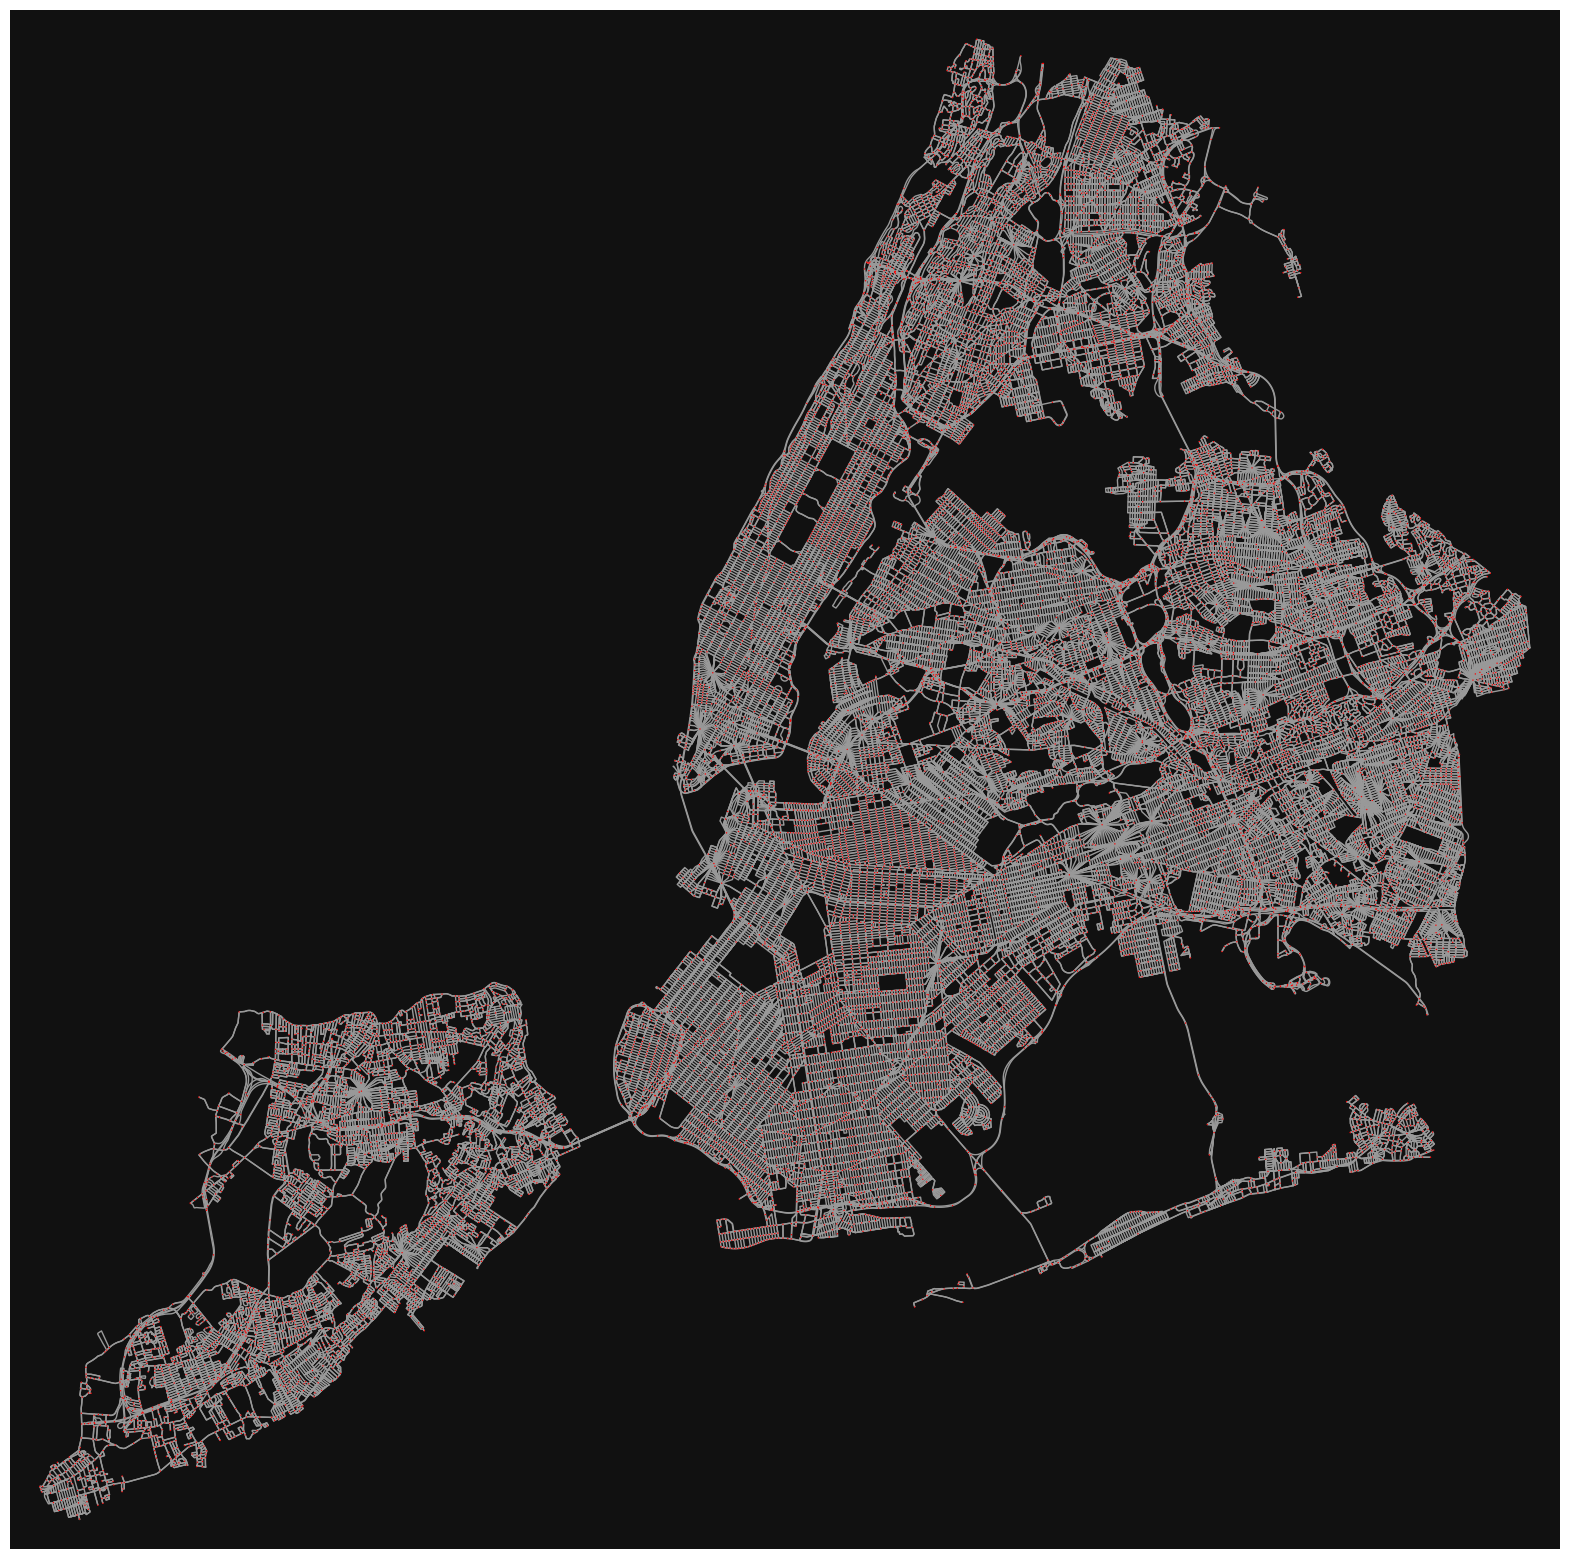

(<Figure size 2000x2000 with 1 Axes>, <Axes: >)

In [13]:
#simplified_graph = osmnx.simplification.consolidate_intersections(graph, tolerance=40)
print(simplified_graph.order())
print(simplified_graph.number_of_edges())
osmnx.plot.plot_graph(simplified_graph, node_size=1, figsize=(20, 20), node_color="#ff0000")

Nous avons réduit de 70% le nombre de nœuds et de 50% celui des arêtes tout en déformant assez peu le réseau (on peut néanmoins observer quelques artefacts en "étoile"). Les statistiques descriptives se feront sur le graphe original.
Intéressons nous maintenant aux déplacements des taxis. En moyenne, au cours de l'année entière, comment se répartissent-ils dans la ville ?

Nombre total de trajets :  2265923306049696000


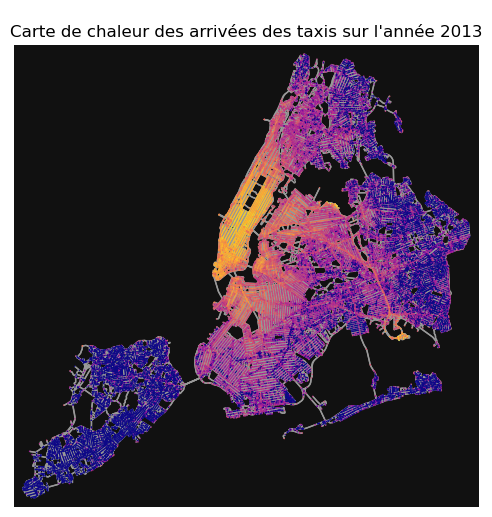

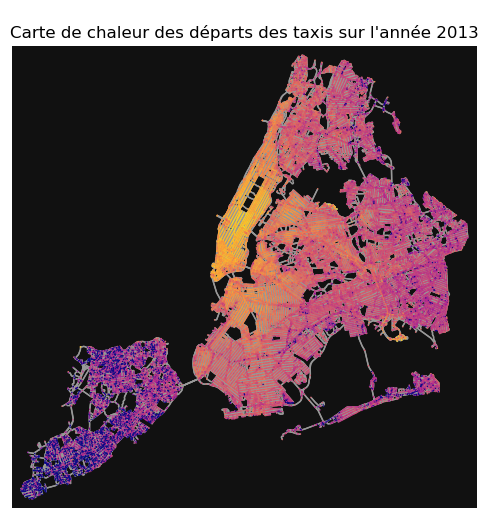

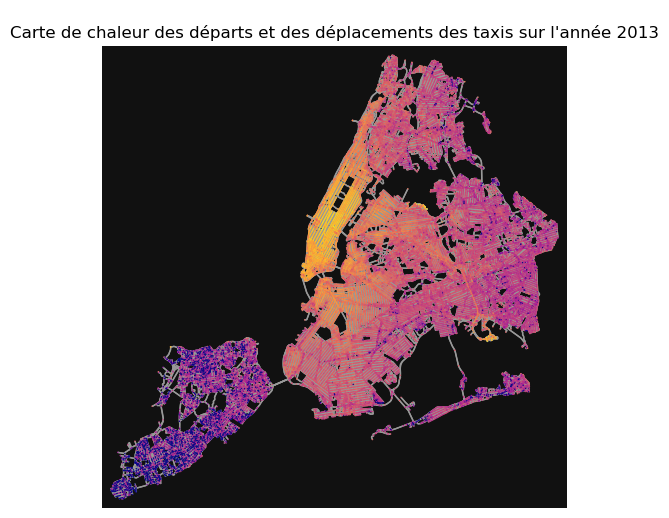

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

start_date = np.datetime64("2013-01-01")
end_date = np.datetime64("2013-12-31")
dates = pd.DataFrame({"start": [start_date], "end": [end_date]})
od_matrix = data_processing.build_raw_od_matrix("data/FOIL2013", dates, graph.order(), norm=False) # La coordonée (i, j) de cette matrice contient le nombre de trajets du sommet i vers le sommet j
# après normalisation
o_matrix = np.sum(od_matrix, axis=1) # Vecteur donnant le nombre de trajets arrivant en un sommet donné
d_matrix = np.sum(od_matrix, axis=0) # Vecteur donnant le nombre de trajets partant en un sommet donné
print("Nombre total de trajets : ", np.sum(od_matrix))

def plot_heatmap(array, title):
    cmap = plt.get_cmap("plasma")
    norm = mcolors.Normalize(vmin=array.min(), vmax=array.max())
    colors = [mcolors.to_hex(cmap(norm(x))) for x in array]
    fig, ax = osmnx.plot.plot_graph(graph, node_color=colors, node_size=1, figsize=(6, 6), show=False, close=False)
    ax.set_title(title)
    plt.show()

plot_heatmap(np.log1p(o_matrix), "Carte de chaleur des arrivées des taxis durant l'année 2013") # Nous prenons le logarithme du fait de la distribution écrasée vers la gauche des données
plot_heatmap(np.log1p(d_matrix), "Carte de chaleur des départs des taxis durant l'année 2013")
plot_heatmap(np.log1p(d_matrix + o_matrix), "Carte de chaleur des départs et des arrivées des taxis durant l'année 2013")

Nous voyons très clairement Manhattan se distinguer sur les cartes. Les départs sont répartis de manière plus uniforme que les arrivées. On remarque des quartier Qu'en est-il si l'on se restreint uniquement à certaines tranches horaires, comme le matin ?

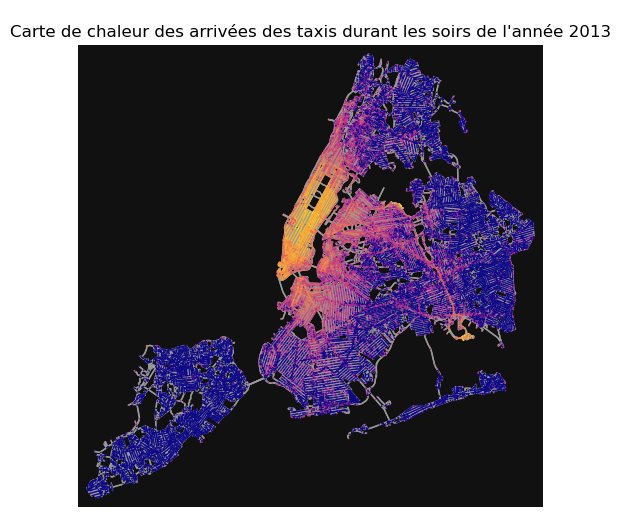

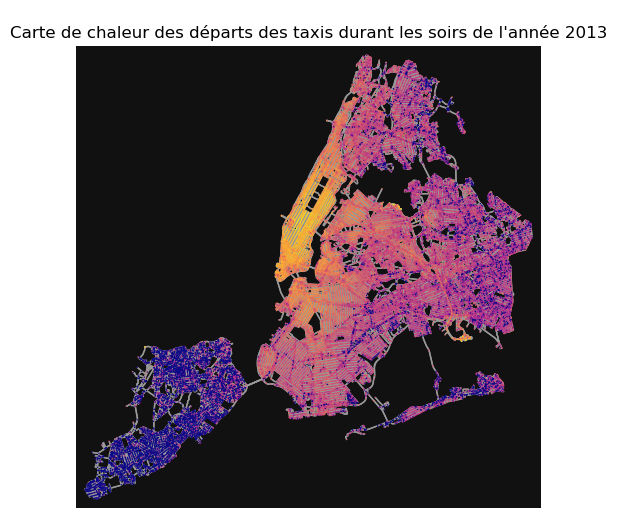

In [43]:
start = np.arange(np.datetime64("2013-01-01T16:00"), np.datetime64("2013-12-31T16:00"), np.timedelta64(1, 'D'))
end = np.arange(np.datetime64("2013-01-01T20:00"), np.datetime64("2013-12-31T20:00"), np.timedelta64(1, 'D'))

dates = pd.DataFrame({"start": pd.to_datetime(start), "end": pd.to_datetime(end)})
od_matrix = data_processing.build_raw_od_matrix("data/FOIL2013", dates, graph.order(), norm=False) 
o_matrix = np.sum(od_matrix, axis=1) 
d_matrix = np.sum(od_matrix, axis=0)
plot_heatmap(np.log1p(o_matrix), "Carte de chaleur des arrivées des taxis durant les soirs de l'année 2013")
plot_heatmap(np.log1p(d_matrix), "Carte de chaleur des départs des taxis durant les soirs de l'année 2013")

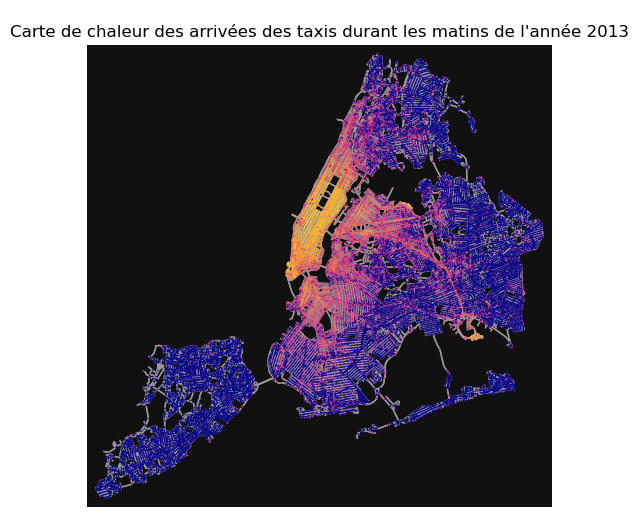

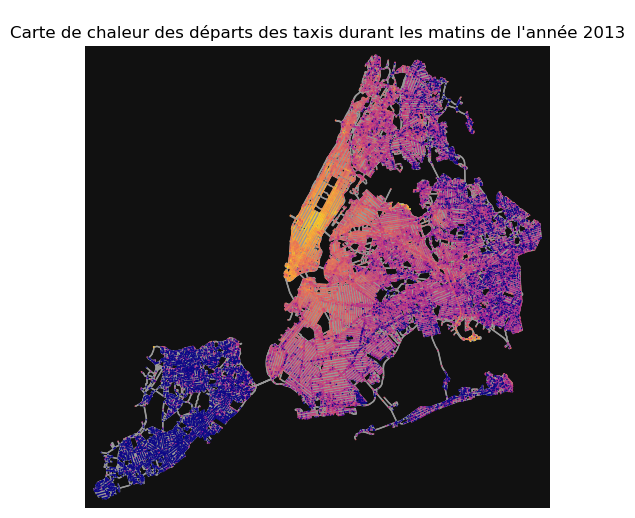

In [45]:
start = np.arange(np.datetime64("2013-01-01T06:00"), np.datetime64("2013-12-31T06:00"), np.timedelta64(1, 'D'))
end = np.arange(np.datetime64("2013-01-01T10:00"), np.datetime64("2013-12-31T10:00"), np.timedelta64(1, 'D'))

dates = pd.DataFrame({"start": pd.to_datetime(start), "end": pd.to_datetime(end)})
od_matrix = data_processing.build_raw_od_matrix("data/FOIL2013", dates, graph.order(), norm=False) 
o_matrix = np.sum(od_matrix, axis=1) 
d_matrix = np.sum(od_matrix, axis=0)
plot_heatmap(np.log1p(o_matrix), "Carte de chaleur des arrivées des taxis durant les matins de l'année 2013")
plot_heatmap(np.log1p(d_matrix), "Carte de chaleur des départs des taxis durant les matins de l'année 2013")

Nous n'observons pas de symétrie particulière entre les déplacements du matin et ceux du soir, en particulier pas de déplacements pendulaires. Malgré tout, au niveau de la ville entière, l'heure le jour influe-t-ils sur le nombre de trajets ?

In [52]:
import pandas as pd
import seaborn as sns

df = pd.read_parquet("data/FOIL2013/trip_data_1.parquet")

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day_name()  # Jour de la semaine
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_date'] = df['pickup_datetime'].dt.date  # Date sans l'heure

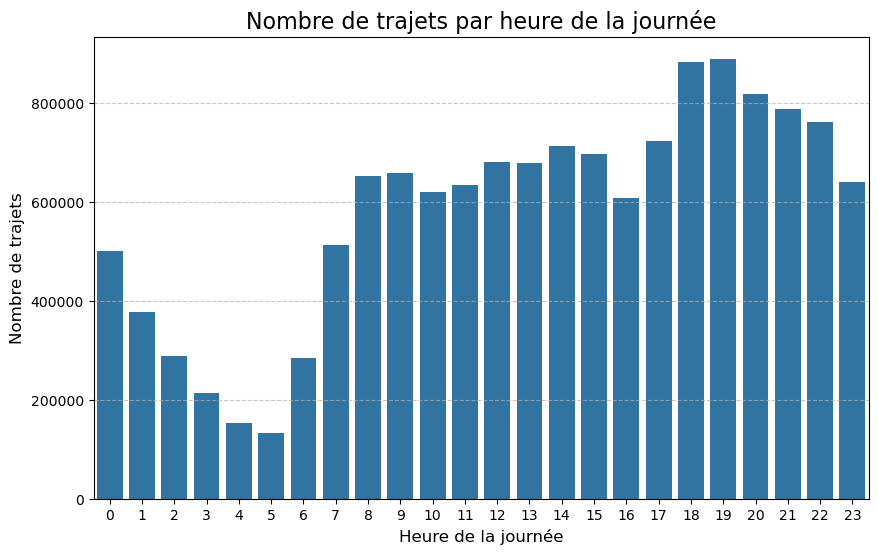

In [53]:
hourly_trips = df['pickup_datetime'].dt.hour.value_counts().sort_index()

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=hourly_trips.index, y=hourly_trips.values)
plt.title("Nombre de trajets par heure de la journée", fontsize=16)
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Sans surprise, peu de taxis circulent entre 00h et 6h. Le pic du traffic a lieu le soir, vers 19h.

/tmp/ipykernel_30600/2800931294.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")


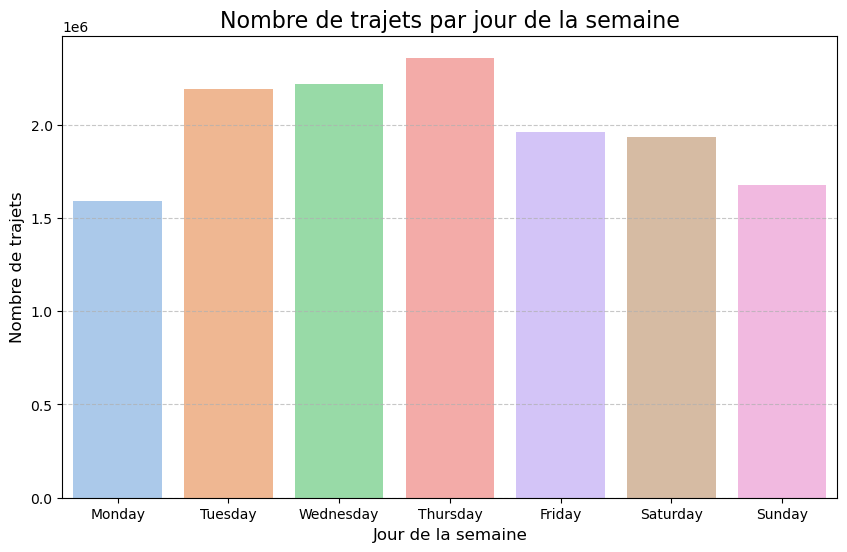

In [59]:
# Compter les trajets par jour de la semaine
weekly_trips = df['pickup_day'].value_counts() 

# Ordonner les jours de la semaine
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_trips = weekly_trips.reindex(ordered_days)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(x=weekly_trips.index, y=weekly_trips.values, palette="pastel")
plt.title("Nombre de trajets par jour de la semaine", fontsize=16)
plt.xlabel("Jour de la semaine", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ce résultat est assez surprenant : il y a moins de circulation le dimanche que le lundi. Le fait que les jours actifs enregistrent une circulation plus élevé était attendu néanmoins.

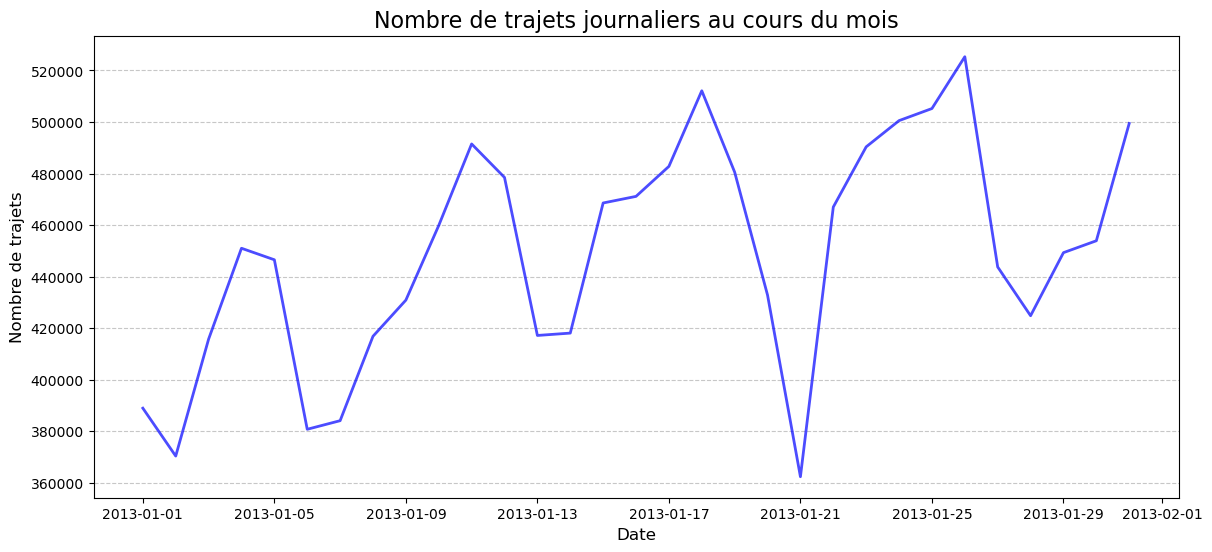

In [56]:
# Compter les trajets par jour du mois
daily_trips = df.groupby('pickup_date').size()

# Visualisation
plt.figure(figsize=(14, 6))
daily_trips.plot(color="blue", alpha=0.7, linewidth=2)
plt.title("Nombre de trajets journaliers au cours du mois", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Les creux périodiques correspondent aux lundis, corroborant ainsi le graphe précédent.
Nous en concluons qu'il est important de considérer les trajets sur sur l'année entière afin de lisser les fluctuations. Il ne semble pas très pertinent de se limiter à des tranches horaires.

In [63]:
import pandas as pd

traffic_volume_counts = pd.read_csv("data/automated_traffic_volume_counts.csv")

In [74]:
sum_volumes = traffic_volume_counts.groupby("street")["Vol"].sum().reset_index()
street_counts = traffic_volume_counts.groupby("street").size().reset_index(name="count")
agg_traffic_volume_counts = pd.merge(sum_volumes, street_counts, on="street")
agg_traffic_volume_counts.head()

,street,Vol,count
0,1 AV,32067,108
1,1 AV W RDWY,12777,199
2,1 AVENUE,799950,6317
3,10 AV,5494,177
4,10 AVENUE,162972,2717


In [80]:
traffic_volume_counts.street.unique()

array(['PULASKI BRIDGE', 'PARSONS BLVD', 'PARK AVENUE', ...,
       'N/B GREAVES AVE @ DEWY AVE', 'WASHINGTON BR EN CROSS BX EXPWY',
       'BELT PARKWAY EB EN 4 AVE'], shape=(2328,), dtype=object)

In [19]:
if gdf.crs is None:
    # Si le CRS n'est pas défini, on l'assigne manuellement à EPSG:4326 (latitude/longitude)
    gdf.set_crs("EPSG:2263", allow_override=True, inplace=True)
elif gdf.crs != "EPSG:2263":
    # Si le CRS est défini mais n'est pas EPSG:4326, on le convertit
    gdf = gdf.to_crs("EPSG:2263")

# Agrégation des données par rue
agg_gdf = gdf.groupby('street').agg({
    'Vol': 'sum',  # Somme des volumes de trafic
    'geometry': 'first'  # Garder la première géométrie (généralement le centroïde)
}).reset_index()


# Agrégation par "street"
aggregated_df = traffic_data.groupby('street').agg(
    Vol=('Vol', 'sum'),  # Additionner les volumes
    Boro=('Boro', 'first'),  # Prendre la première valeur pour "Boro"
    SegmentID=('SegmentID', 'first'),  # Prendre la première valeur pour "SegmentID"
    WktGeom=('WktGeom', 'first'),  # Prendre la première valeur pour "WktGeom"
    fromSt=('fromSt', 'first'),  # Prendre la première valeur pour "fromSt"
    toSt=('toSt', 'first'),  # Prendre la première valeur pour "toSt"
    Direction=('Direction', 'first'),  # Prendre la première valeur pour "Direction"
    datetime=('datetime', 'min')  # Prendre la première date (vous pouvez utiliser 'min' ou 'max' selon vos besoins)
).reset_index()

In [ ]:
traffic_data

In [ ]:
from folium import Choropleth
from IPython.display import IFrame


m = folium.Map(location=[40.7128, -74.0060], zoom_start=12)

for idx, row in agg_gdf.iterrows():
    # Utiliser le centroïde de la géométrie pour le placement du cercle
    if row['geometry'].is_valid:  # Vérifier la validité de la géométrie
        centroid = row['geometry'].centroid
        traffic_volume = row['Vol']
        radius = min(traffic_volume / 100, 50)  # La taille du cercle est proportionnelle au volume de trafic, avec un maximum de rayon de 50

        # Ajouter un cercle sur la carte
        folium.CircleMarker(
            location=[centroid.y, centroid.x],  # Utiliser le centroïde de la géométrie pour le placement du cercle
            radius=radius,  # Taille du cercle
            color='blue',  # Couleur du cercle
            fill=True,
            fill_color='blue',  # Couleur de remplissage
            fill_opacity=0.6,  # Opacité du remplissage
            tooltip=f"Street: {row['street']}<br>Traffic Volume: {traffic_volume}"  # Tooltip pour chaque cercle
        ).add_to(m)

# Afficher la carte directement dans le notebook
m

# III. Modélisation

Nous commençons par récupérer l'intégralité des trajets réalisés durant l'année, que nous stockons dans une matrice origine-destination

In [22]:
import numpy as np

dates = pd.DataFrame({"start": [np.datetime64("2013-01-01")], "end": [np.datetime64("2013-12-31")]})
od_demand = data_processing.build_raw_od_matrix("data/FOIL2013", dates, graph.order())

Par la suite, nous exploitons les données d'OpenStreetMaps pour récupérer des informations comme le nombre de voies ou le temps de trajet.  Nous complétons les valeurs manquantes par les moyennes des colonnes. Nous nous servons de ses paramètres pour définir la capacité des voie, qui représentent en quelque sorte le nombre maximal de voitures qui peuvent circuler à travers une voie par unité de temps. 

In [23]:
lanes = []
maxspeeds = []
lengths = []
nodes = []
travel_times = []

for u, v, data in graph.edges(data=True):
    nodes.append((u, v))
    if "lanes" in data:
        if isinstance(data["lanes"], list):
            lanes.append(float(data["lanes"][0]))
        else:
            lanes.append(float(data["lanes"]))
    else:
        lanes.append(np.nan)
    travel_times.append(float(data.get("travel_time", np.nan)))
    maxspeeds.append(float(data.get("speed_kph", np.nan)))
    lengths.append(float(data.get("length", np.nan)))

data_edges = pd.DataFrame(data = {"lanes": lanes, "maxspeed": maxspeeds, "length": lengths, "travel_time": travel_times}, index = pd.MultiIndex.from_tuples(nodes, names=["u", "v"]))

for col in data_edges.columns:
    data_edges[data_edges[col].isna()] = data_edges[col].mean()

data_edges["capacity"] = data_edges["length"] / (4.48 + data_edges["maxspeed"] * 6)


Nous définissons les paramètres utiles au modèle, en particulier la fonction de coût. Il s'agit ici de la fonction Bureau of Public Roads (BPR) dont l'expression est
${f(x) = t_0(1 + \alpha(x / c)^{\beta})}$,
où ${f(x)}$ est le temps de trajet de la voie donnée avec un flux de ${x}$ conducteurs, ${t_0}$ est le temps de trajet à vide, ${c}$ la capacité de la voie et ${\alpha}$ et ${\beta}$ des paramètres à ajuster. Nous reprenons les valeurs usuelles pour ces paramètres, c'est-à-dire ${\alpha = 0,15}$ et ${\beta = 4}$.

In [26]:
import graph_tool.all as gt
import networkx as nx

a = 0.15
b = 4

gt_graph = gt.Graph(nx.to_scipy_sparse_array(graph))
A, B, C, T0, back = [gt_graph.new_edge_property("float", val=0) for _ in range(5)]
num_edges = gt_graph.num_edges()

A.a = a * np.ones(num_edges)
B.a = b * np.ones(num_edges)

for row in data_edges.itertuples(index=True, name='Pandas'):
    edge = gt_graph.edge(*row.Index)
    C[edge] = row.capacity
    T0[edge] = row.travel_time

params = [A, B, C, T0]
demand_coo = od_demand.tocoo()
demand  = {(r, c): v for r, c, v in zip(demand_coo.row, demand_coo.col, demand_coo.data)}

itapas_solver = solver.ITAPAS(gt_graph, params, back, solver.bpr_function)

Nous calculons ensuite l'assignation, tâche qui prend environ 8 heures et demande beaucoup de ressources. Nous sauvegardons le résultat, de manière à pouvoir exploiter les résultats sans relancer à nouveau le solveur.

In [ ]:
params={
            "epsilon": 1e-12,
            "theta": 1e-12,
            "mu": 1e-3,
            "nu": 0.5,
            "dg": 100,
            "time": 120_000,
            "iter": 200,
            "out_flag": True,
        }

link_flow, link_flow_node = itapas_solver.assign(demand, params = params)
np.save("link_flow_ny_full.npy", link_flow.a)

À lancer si la cellule précédente n'a pas été exécutée.

In [46]:
import graph_tool.all as gt
import networkx as nx

gt_graph = gt.Graph(nx.to_scipy_sparse_array(graph))
link_flow = gt_graph.new_edge_property("float", val=0)
link_flow.a = np.load("link_flow_ny_full.npy")

# IV. Résultats et conclusion

Étant donné que nous ne faisons qu'assigner le flux des voyageurs, la somme des flux des arêtes devrait être égale à celle des coordonnées de la matrice origine-demande. Il ne s'agit malheureusement pas du cas ici, du fait de la précision volontairement abaissée du modèle. Il aurait pris bien trop de temps à être exécuté sinon. Les résultats sont donc inexploitables. Nous représentons malgré tout l'assignation calculée sur une carte de New York, mais elle est difficilement interprétable.

In [ ]:
print(np.sum(link_flow.a))
print(np.sum(od_demand))

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

cmap = plt.get_cmap("plasma")
norm = mcolors.Normalize(vmin=link_flow.a.min(), vmax=link_flow.a.max())
colors = [mcolors.to_hex(cmap(norm(x))) for x in link_flow.a]
routes = [list(edge) for edge in gt_graph.edges()]
osmnx.plot.plot_graph_routes(graph, routes, route_colors = colors, node_size=1, figsize=(20, 20), route_linewidths=1)
